# EDA — NC Restaurant Inspections + Google Reviews

AI-assisted (Claude Code, claude.ai) — https://claude.ai

Core questions:
1. How severe is class imbalance in grades?
2. What does the score distribution look like and how does it map to grade?
3. How well do inspections join to Google reviews?
4. Does Google rating correlate with inspection grade?
5. How does grade vary by establishment type and year?

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("Set2")

DATA = os.path.join(os.path.dirname(os.getcwd()), "data", "raw")
GRADE_ORDER = ["A", "B", "C"]

## 1. Load data

In [2]:
# Load yearly inspection files and tag each with the source year
yearly_files = sorted(glob.glob(os.path.join(DATA, "inspections_20*.csv")))

frames = []
for path in yearly_files:
    year = int(os.path.basename(path).replace("inspections_", "").replace(".csv", ""))
    df = pd.read_csv(path)
    df["year"] = year
    frames.append(df)

insp = pd.concat(frames, ignore_index=True)
insp["grade"] = insp["grade"].str.strip()
insp = insp[insp["grade"].isin(GRADE_ORDER)]  # drop the 208 ungraded rows

google = pd.read_csv(os.path.join(DATA, "google_reviews.csv"))
google["google_rating"] = pd.to_numeric(google["google_rating"], errors="coerce")
google["match_score"] = pd.to_numeric(google["match_score"], errors="coerce")

print(f"Inspections: {len(insp):,} rows | Google reviews: {len(google):,} rows")
insp.head(3)

Inspections: 227,070 rows | Google reviews: 17,931 rows


,county_code,establishment_id,inspection_id,inspection_date,establishment_name,street_address,city,zip,state_id,establishment_type,score,grade,inspector_id,year
0,1,NaN,NaN,NaN,GRILL 5*8*4,770 HUFFMAN MILL RD,BURLINGTON,27215,3001010990,1 - Restaurant,97.0,A,2757.0,2020
1,1,NaN,NaN,NaN,ARMC KITCHEN,1240 HUFFMAN MILL RD,BURLINGTON,27215,3001010365,1 - Restaurant,98.5,A,2757.0,2020
2,1,NaN,NaN,NaN,DA VINCI'S TABLE,2260 S CHURCH ST,BURLINGTON,27215,3001011179,1 - Restaurant,98.0,A,2005.0,2020


## 2. Class imbalance

The most important structural fact about this dataset.

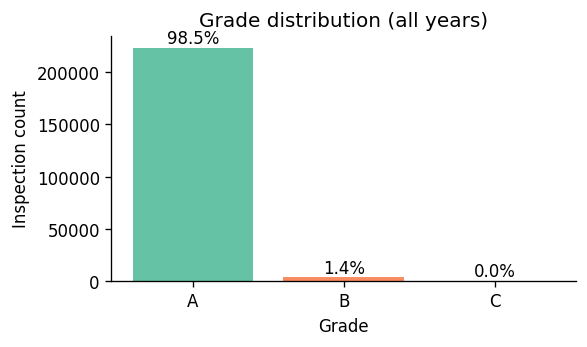

grade
A    223756
B      3209
C       105
Name: count, dtype: int64

Minority class (B+C) share: 1.46%


In [3]:
grade_counts = insp["grade"].value_counts().reindex(GRADE_ORDER)
grade_pct = grade_counts / grade_counts.sum() * 100

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(grade_counts.index, grade_counts.values, color=sns.color_palette("Set2", 3))
for bar, pct in zip(bars, grade_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)
ax.set_xlabel("Grade")
ax.set_ylabel("Inspection count")
ax.set_title("Grade distribution (all years)")
plt.tight_layout()
plt.show()

print(grade_counts)
print(f"\nMinority class (B+C) share: {100 - grade_pct['A']:.2f}%")

## 3. Score distribution and grade thresholds

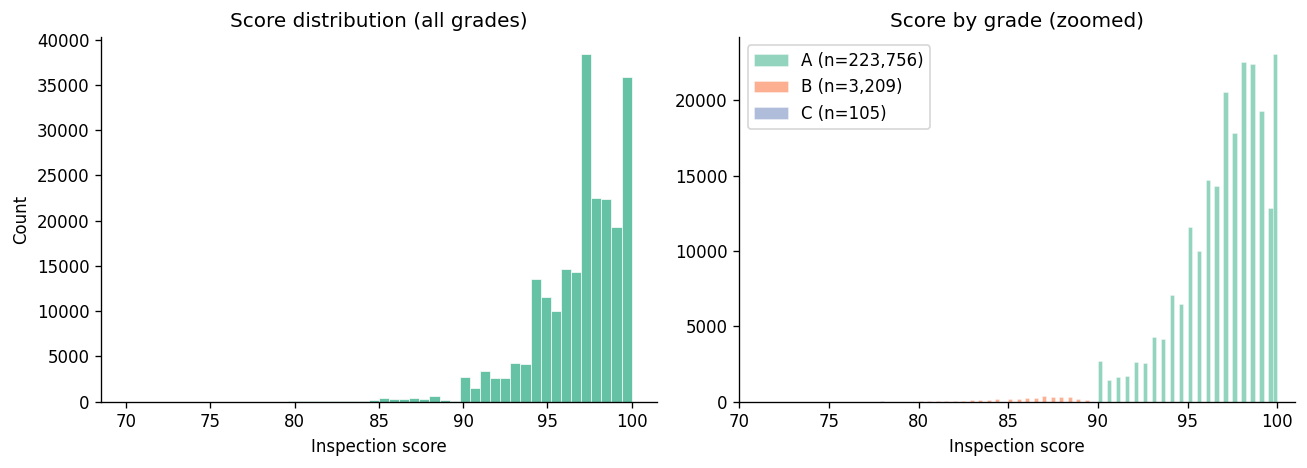

          count   mean   std   min   25%   50%   75%    max
grade                                                      
A      223756.0  97.02  2.29  90.0  95.5  97.5  98.5  100.0
B        3209.0  86.11  2.24  80.0  85.0  86.5  88.0   89.5
C         105.0  76.15  2.59  70.0  75.0  77.0  78.0   79.5


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Full score histogram
axes[0].hist(insp["score"], bins=50, edgecolor="white", linewidth=0.4)
axes[0].set_xlabel("Inspection score")
axes[0].set_ylabel("Count")
axes[0].set_title("Score distribution (all grades)")

# Score by grade — zoom into meaningful range
palette = {"A": "#66c2a5", "B": "#fc8d62", "C": "#8da0cb"}
for grade in GRADE_ORDER:
    subset = insp[insp["grade"] == grade]["score"]
    axes[1].hist(subset, bins=40, alpha=0.7, label=f"{grade} (n={len(subset):,})",
                 color=palette[grade], edgecolor="white", linewidth=0.3)
axes[1].set_xlim(70, 101)
axes[1].set_xlabel("Inspection score")
axes[1].set_title("Score by grade (zoomed)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(insp.groupby("grade")["score"].describe().round(2))

## 4. Grade trends by year

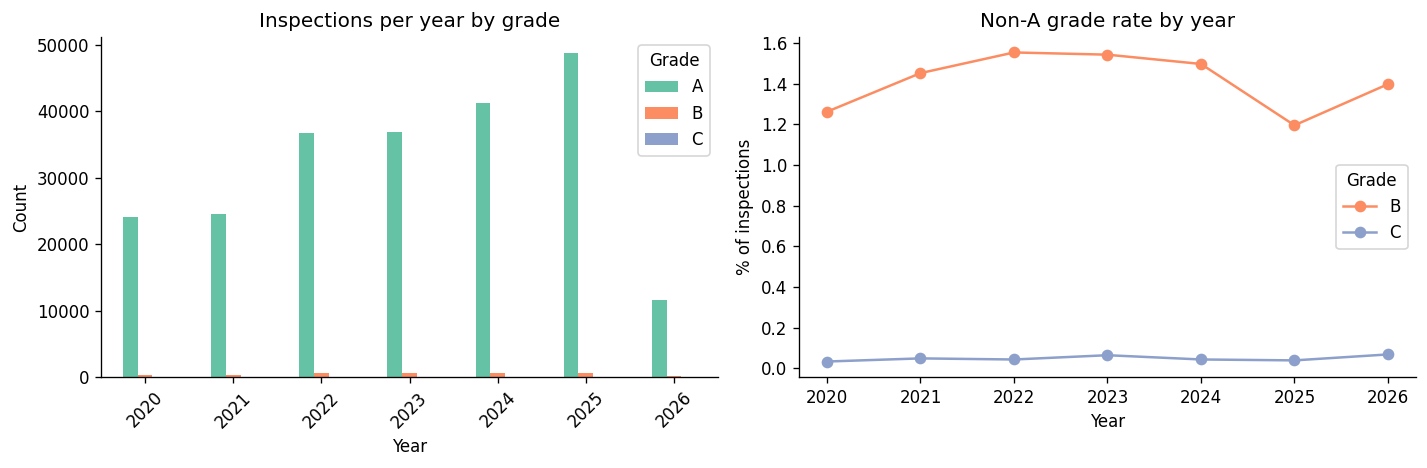

grade      A     B     C
year                    
2020   98.71  1.26  0.03
2021   98.50  1.45  0.05
2022   98.40  1.55  0.04
2023   98.39  1.54  0.06
2024   98.46  1.50  0.04
2025   98.77  1.20  0.04
2026   98.53  1.40  0.07


In [5]:
yearly = (
    insp.groupby(["year", "grade"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=GRADE_ORDER)
)
yearly_pct = yearly.div(yearly.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

yearly.plot(kind="bar", ax=axes[0], color=[palette[g] for g in GRADE_ORDER])
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].set_title("Inspections per year by grade")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Grade")

yearly_pct[["B", "C"]].plot(ax=axes[1], marker="o", color=[palette["B"], palette["C"]])
axes[1].set_xlabel("Year")
axes[1].set_ylabel("% of inspections")
axes[1].set_title("Non-A grade rate by year")
axes[1].legend(title="Grade")

plt.tight_layout()
plt.show()

print(yearly_pct.round(2))

## 5. Grade by establishment type

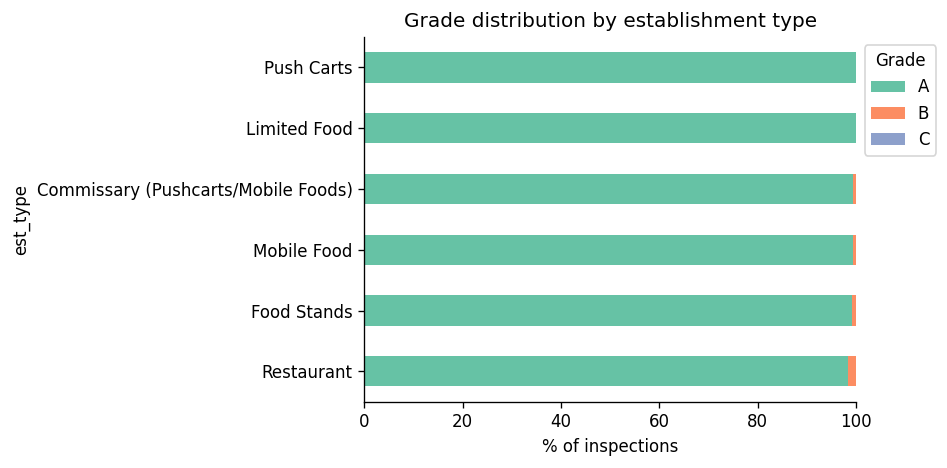

grade                                     A     B   C   total
est_type                                                     
Restaurant                           168224  2752  95  171071
Food Stands                           42190   383   9   42582
Mobile Food                           10428    69   1   10498
Limited Food                           1364     0   0    1364
Commissary (Pushcarts/Mobile Foods)     855     5   0     860
Push Carts                              695     0   0     695


In [6]:
# Simplify type labels
type_label = insp["establishment_type"].str.extract(r"\d+ - (.+)")[0]
insp["est_type"] = type_label

type_grade = (
    insp.groupby(["est_type", "grade"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=GRADE_ORDER)
)
type_grade_pct = type_grade.div(type_grade.sum(axis=1), axis=0) * 100
type_grade_pct = type_grade_pct.sort_values("A")

fig, ax = plt.subplots(figsize=(8, 4))
type_grade_pct.plot(kind="barh", stacked=True, ax=ax,
                    color=[palette[g] for g in GRADE_ORDER])
ax.set_xlabel("% of inspections")
ax.set_title("Grade distribution by establishment type")
ax.legend(title="Grade", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# Total counts per type
print(type_grade.assign(total=type_grade.sum(axis=1)).sort_values("total", ascending=False))

## 6. Google reviews join quality

In [ ]:
# Unique restaurants in each source (deduplicated by state_id)
insp_restaurants = insp.drop_duplicates("state_id")
google_restaurants = google.drop_duplicates("state_id")

# Cast to same type to avoid int/float merge warning
insp_restaurants = insp_restaurants.copy()
insp_restaurants["state_id"] = insp_restaurants["state_id"].astype(float)

merged = insp_restaurants[["state_id", "grade"]].merge(
    google_restaurants[["state_id", "google_rating", "google_review_count", "match_score"]],
    on="state_id",
    how="left",
)
match_rate = merged["google_rating"].notna().mean() * 100

print(f"Unique restaurants in inspections: {len(insp_restaurants):,}")
print(f"Unique restaurants in Google data: {len(google_restaurants):,}")
print(f"state_id join match rate: {match_rate:.1f}%")

# Match score distribution
fig, ax = plt.subplots(figsize=(6, 3))
google["match_score"].dropna().hist(bins=40, ax=ax, edgecolor="white", linewidth=0.4)
ax.axvline(80, color="red", linestyle="--", label="threshold=80")
ax.set_xlabel("Match score")
ax.set_ylabel("Count")
ax.set_title("Distribution of name-match confidence scores")
ax.legend()
plt.tight_layout()
plt.show()

high_conf = (google["match_score"] >= 80).sum()
total_scored = google["match_score"].notna().sum()
print(f"\nMatches with score >= 80: {high_conf:,} / {total_scored:,} ({high_conf/total_scored*100:.1f}%)")
print("Note: state_id join and fuzzy match_score are independent — high join rate does not imply high confidence.")

## 7. Google rating vs inspection grade

## 6b. Google rating vs grade — high-confidence matches only (score ≥ 80)

Repeats section 7 restricted to matches where the fuzzy name+address confidence is high.
If the pattern holds here, the signal is real. If it disappears, section 7 results are noise from bad links.

In [ ]:
high_conf_google = google[google["match_score"] >= 80][["state_id", "google_rating"]].dropna().drop_duplicates("state_id")

latest_grade = insp.copy()
latest_grade["state_id"] = latest_grade["state_id"].astype(float)
latest_grade = latest_grade.groupby("state_id")["grade"].last().reset_index()

rating_grade_hc = latest_grade.merge(high_conf_google, on="state_id")
print(f"High-confidence matched restaurants: {len(rating_grade_hc):,}")
print(rating_grade_hc["grade"].value_counts().reindex(GRADE_ORDER))

if len(rating_grade_hc) < 10:
    print("\nToo few high-confidence matches to plot — Google link is unreliable for modeling.")
else:
    grade_present_hc = [g for g in GRADE_ORDER if g in rating_grade_hc["grade"].values]
    fig, ax = plt.subplots(figsize=(5, 3))
    data_hc = [rating_grade_hc[rating_grade_hc["grade"] == g]["google_rating"] for g in grade_present_hc]
    bp = ax.boxplot(data_hc, tick_labels=grade_present_hc, patch_artist=True)
    for patch, grade in zip(bp["boxes"], grade_present_hc):
        patch.set_facecolor(palette[grade])
    ax.set_xlabel("Inspection grade")
    ax.set_ylabel("Google rating")
    ax.set_title("Google rating by grade (match_score ≥ 80 only)")
    plt.tight_layout()
    plt.show()
    print(rating_grade_hc.groupby("grade")["google_rating"].describe().round(3))

In [ ]:
# Per-restaurant: take the most recent grade (last inspection by order in file)
latest_grade = insp.copy()
latest_grade["state_id"] = latest_grade["state_id"].astype(float)
latest_grade = latest_grade.groupby("state_id")["grade"].last().reset_index()

rating_grade = latest_grade.merge(
    google[["state_id", "google_rating"]].dropna().drop_duplicates("state_id"),
    on="state_id",
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Box plot
grade_present = [g for g in GRADE_ORDER if g in rating_grade["grade"].values]
data_by_grade = [rating_grade[rating_grade["grade"] == g]["google_rating"] for g in grade_present]
bp = axes[0].boxplot(data_by_grade, tick_labels=grade_present, patch_artist=True)
for patch, grade in zip(bp["boxes"], grade_present):
    patch.set_facecolor(palette[grade])
axes[0].set_xlabel("Inspection grade")
axes[0].set_ylabel("Google rating")
axes[0].set_title("Google rating by inspection grade (all state_id matches)")

# Histogram overlay
for grade in grade_present:
    subset = rating_grade[rating_grade["grade"] == grade]["google_rating"]
    axes[1].hist(subset, bins=20, alpha=0.6, label=f"{grade} (n={len(subset)})",
                 color=palette[grade])
axes[1].set_xlabel("Google rating")
axes[1].set_title("Rating distribution by grade")
axes[1].legend()

plt.tight_layout()
plt.show()

print(rating_grade.groupby("grade")["google_rating"].describe().round(3))

## 8. Review count and text length

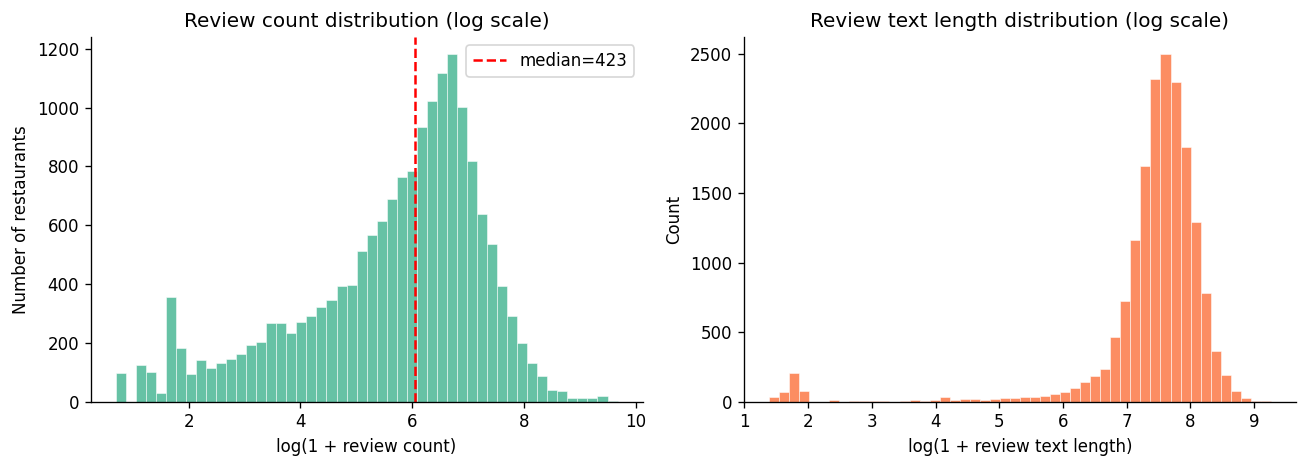

Median review count: 423
Restaurants with >500 reviews: 7,794
Rows with non-null review text: 17,224 / 17,931


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Review count (log scale)
review_counts = google["google_review_count"].dropna()
axes[0].hist(np.log1p(review_counts), bins=50, edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("log(1 + review count)")
axes[0].set_ylabel("Number of restaurants")
axes[0].set_title("Review count distribution (log scale)")
axes[0].axvline(np.log1p(review_counts.median()), color="red", linestyle="--",
                label=f"median={int(review_counts.median())}")
axes[0].legend()

# Concatenated review text length
review_len = google["google_reviews"].dropna().str.len()
axes[1].hist(np.log1p(review_len), bins=50, edgecolor="white", linewidth=0.3, color="#fc8d62")
axes[1].set_xlabel("log(1 + review text length)")
axes[1].set_ylabel("Count")
axes[1].set_title("Review text length distribution (log scale)")

plt.tight_layout()
plt.show()

print(f"Median review count: {review_counts.median():.0f}")
print(f"Restaurants with >500 reviews: {(review_counts > 500).sum():,}")
print(f"Rows with non-null review text: {google['google_reviews'].notna().sum():,} / {len(google):,}")

## 9. Missing data summary

In [10]:
def null_summary(df, name):
    s = df.isnull().sum()
    pct = (s / len(df) * 100).round(1)
    result = pd.DataFrame({"null_count": s, "null_pct": pct})
    result = result[result["null_count"] > 0].sort_values("null_pct", ascending=False)
    print(f"--- {name} ({len(df):,} rows) ---")
    print(result.to_string() if not result.empty else "No nulls.")
    print()

null_summary(insp, "inspections (all years)")
null_summary(google, "google_reviews")

--- inspections (all years) (227,070 rows) ---
                  null_count  null_pct
establishment_id      227070     100.0
inspection_id         227070     100.0
inspection_date       227070     100.0
zip                      269       0.1

--- google_reviews (17,931 rows) ---
                     null_count  null_pct
google_rating              1033       5.8
google_reviews              707       3.9
google_review_count         663       3.7
match_score                 400       2.2



## 10. Key takeaways

| Finding | Implication |
|---|---|
| ~98% of inspections are grade A | Severe class imbalance — accuracy is a misleading metric; use F1/AUC on minority class |
| B/C threshold is ~90/80 in score | Score is a near-perfect grade predictor — exclude it from features to prevent data leakage |
| state_id join matches 51.8% of restaurants, but fuzzy match_score ≥ 80 is < 1% of Google rows | The Google link is mostly low-confidence; treat all Google features as weakly trusted and verify signal on high-confidence subset (see §6b) |
| Google rating weakly correlates with grade on all matches | Rating alone is insufficient; check §6b — if signal disappears on high-confidence matches, rating is not a usable feature |
| Establishment type predicts grade | Include as a categorical feature |
| `inspection_date` is fully null | Year-level temporal analysis requires the yearly files directly |